## Summary
The omnibus Kruskal–Wallis test ($p = 0.0374$) indicates a significant shift in the correlation structure of crime across the three eras, with median correlation distances declining from Pre-COVID to Post-COVID. This downward trend suggests increasing synchronization among crime types over time, though the Pre-COVID vs. Post-COVID contrast does not survive Bonferroni correction and should be interpreted as emerging rather than conclusive.

The most robust structural change occurred between the Pre-COVID and COVID periods ($p = 0.0127$), when crime types became significantly more synchronized, consistent with COVID acting as a systemic shock that constrained and aligned criminal activity. The absence of a significant difference between the COVID and Post-COVID periods ($p = 0.2812$) indicates that this elevated synchronization has persisted, supporting the emergence of a post-pandemic “new normal” rather than a reversion to pre-COVID dynamics.

During COVID, the largest structural shifts were concentrated in mobility and street-level offenses, particularly Drug Abuse Violations, Robbery, Burglary, Liquor Law violations, and Criminal Sexual Abuse, reflecting sensitivity to lockdowns and reduced public activity. In the Post-COVID era, the greatest movement shifted toward weapons-related and financial crimes, led by Weapons Violations and Embezzlement, while offenses such as Fraud, Gambling, Stolen Property, Drug Abuse Violations, and Disorderly Conduct remained comparatively stable.

In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.feather as feather
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import procrustes
from scipy.stats import zscore
from sklearn.decomposition import PCA
from importlib.metadata import version

# python source path
sys.path.append('../Src/')
# Set seed
SEED = 1776

# custom python
import plot
import utils
import zscore_anomaly
import evaluate_clusters

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Pyarrow": pa.__version__, 
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    "Sk-Learn": sys.modules['sklearn'].__version__
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)
# reset options
# pd.reset_option('display.max_columns')

# Use a single Arrow string & int64 type instance to save memory
arrow_string = pd.ArrowDtype(pa.string())
arrow_int32 = pd.ArrowDtype(pa.int32())
arrow_cat8 = pd.ArrowDtype(pa.dictionary(index_type=pa.int8(), value_type=pa.string()))
arrow_cat16 = pd.ArrowDtype(pa.dictionary(index_type=pa.int16(), value_type=pa.string()))
arrow_cat32 = pd.ArrowDtype(pa.dictionary(index_type=pa.int32(), value_type=pa.string()))

    Library Version
0    Python  3.13.9
1    Pandas   2.3.3
2     NumPy   2.3.4
3   Pyarrow  22.0.0
4   Seaborn  0.13.2
5   Matplot  3.10.7
6  Sk-Learn   1.8.0


## Data Import

In [2]:
# PyArrow's version of the 'arrow' backend
df = feather.read_feather('../Data/crime_data_covid.feather', memory_map=True, types_mapper=pd.ArrowDtype)
# display
df.head()

,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,sector,ward,community_code,community_name,community_area,fbi_code,x_coordinate,y_coordinate,year,latitude,longitude,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location,year_week,era,Indexed
0,01G050460,2001-01-24 20:45:00,072XX S RIDGELAND AV,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,0324,003,1,<NA>,<NA>,<NA>,<NA>,18,1189075,1857566,2001,41.764219,-87.582549,January,Wednesday,Q1,2001-Q1,Night,Drug Abuse Violations,False,Grand Crossing,2001-04,pre_covid,N
1,03J493690,2003-07-12 17:00:00,075XX S DOBSON AVE,0890,THEFT,FROM BUILDING,APARTMENT,False,False,0624,006,2,08,69,GREATER GRAND CROSSING,98853167.7093,06,1184198,1855214,2003,41.75788,-87.600498,July,Saturday,Q3,2003-Q3,Evening,Larceny – Theft,True,Gresham,2003-28,pre_covid,I
2,04X245238,2004-12-13 21:15:00,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,True,False,1122,011,4,27,23,HUMBOLDT PARK,100480876.502,18,1151273,1903996,2004,41.892451,-87.719888,December,Monday,Q4,2004-Q4,Night,Drug Abuse Violations,False,Harrison,2004-51,pre_covid,N
3,07C115980,2006-03-31 09:15:00,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,False,2512,025,5,29,19,BELMONT CRAGIN,109099414.689,05,1133296,1916864,2006,41.928096,-87.78561,March,Friday,Q1,2006-Q1,Morning,Burglary,True,Grand Central,2006-13,pre_covid,I
4,07HN36467,2007-05-25 14:51:00,022XX N LA CROSSE AVE,1812,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,True,False,2522,025,5,31,19,BELMONT CRAGIN,109099414.689,18,1143697,1914371,2007,41.921066,-87.747452,May,Friday,Q2,2007-Q2,Afternoon,Drug Abuse Violations,False,Grand Central,2007-21,pre_covid,N


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469443 entries, 0 to 8469442
Data columns (total 33 columns):
 #   Column                Dtype                                                       
---  ------                -----                                                       
 0   case_number           string[pyarrow]                                             
 1   date                  timestamp[s][pyarrow]                                       
 2   block                 string[pyarrow]                                             
 3   iucr                  string[pyarrow]                                             
 4   primary_type          string[pyarrow]                                             
 5   description           string[pyarrow]                                             
 6   location_description  string[pyarrow]                                             
 7   arrest                bool[pyarrow]                                               
 8   do

## The Timeline Definition
* To ensure the analysis is accurate, we define the three eras based on global lockdown patterns:
    * Pre-COVID: January 2001 – February 2020
    * COVID Era: March 2020 – December 31, 2022
    * Post-COVID: January 2023 – Present

In [4]:
# Create the new column using .dt.strftime (Unit of Analysis: Year & Month)
df['year_month'] = df['date'].dt.strftime('%Y%m')

# convert year_month to int
df.year_month = df.year_month.astype(arrow_int32)
# check the datatype
print(df.year_month.dtype)
# display
df[['date','year_month']].head()

int32[pyarrow]


,date,year_month
0,2001-01-24 20:45:00,200101
1,2003-07-12 17:00:00,200307
2,2004-12-13 21:15:00,200412
3,2006-03-31 09:15:00,200603
4,2007-05-25 14:51:00,200705


In [5]:
df.era.unique()

<ArrowExtensionArray>
['pre_covid', 'post_covid', 'covid']
Length: 3, dtype: dictionary<values=string, indices=int32, ordered=0>[pyarrow]

In [6]:
# Spearate Era
df_pre = df[df.era == 'pre_covid']
df_covid = df[df.era == 'covid']
df_post = df[df.era == 'post_covid']
# display shape
df_pre.shape, df_covid.shape, df_post.shape

((7092647, 34), (624045, 34), (752751, 34))

## Data Prep

In [7]:
# Time & Crime Type
matrix_pre = df_pre.groupby(['year_month', 'fbi_code_desc']).size()
matrix_pre.sort_index(inplace=True)
#
matrix_covid = df_covid.groupby(['year_month', 'fbi_code_desc']).size()
matrix_covid.sort_index(inplace=True)
#
matrix_post = df_post.groupby(['year_month', 'fbi_code_desc']).size()
matrix_post.sort_index(inplace=True)

# # Replace index 'year_month' to int32
# master_matrix.index = master_matrix.index.set_levels(
#     master_matrix.index.get_level_values('year_month').astype(arrow_int32), 
#     level='year_month'
# )
# Returns a Series where the index is the level name and the value is the dtype
print(matrix_pre.index.dtypes)
# Multiindex name
print(matrix_pre.index.names, "\n")
print(matrix_pre.index.min(), matrix_pre.index.max())
print(matrix_covid.index.min(), matrix_covid.index.max())
print(matrix_post.index.min(), matrix_post.index.max(), "\n")
# convert this Series to a DataFrame
matrix_flat_pre = matrix_pre.reset_index(name="crime_count")
matrix_flat_covid = matrix_covid.reset_index(name="crime_count")
matrix_flat_post = matrix_post.reset_index(name="crime_count")

year_month                                                     int32[pyarrow]
fbi_code_desc    dictionary<values=string, indices=int32, ordered=0>[pyarrow]
dtype: object
['year_month', 'fbi_code_desc'] 

(200101, 'Aggravated Assault') (202002, 'Weapons Violations')
(202003, 'Aggravated Assault') (202301, 'Weapons Violations')
(202301, 'Aggravated Assault') (202512, 'Weapons Violations') 



In [8]:
# Only Keeping Three years Pre-COVID
matrix_flat_pre = matrix_flat_pre[matrix_flat_pre.year_month > 201612]

# Prevent Arrow Error
matrix_flat_pre.fbi_code_desc = matrix_flat_pre.fbi_code_desc.astype(str)
matrix_flat_covid.fbi_code_desc = matrix_flat_covid.fbi_code_desc.astype(str)
matrix_flat_post.fbi_code_desc = matrix_flat_post.fbi_code_desc.astype(str)

# Pivot
z_pivot_pre = matrix_flat_pre.pivot(index='fbi_code_desc', columns='year_month', values='crime_count').fillna(0)
z_pivot_covid = matrix_flat_covid.pivot(index='fbi_code_desc', columns='year_month', values='crime_count').fillna(0)
z_pivot_post = matrix_flat_post.pivot(index='fbi_code_desc', columns='year_month', values='crime_count').fillna(0)

# print shape
print("DataFrame Pre-Covid shape:", z_pivot_pre.shape)
print("DataFrame Covid shape:", z_pivot_covid.shape)
print("DataFrame Post-Covid shape:", z_pivot_post.shape, "\n")

DataFrame Pre-Covid shape: (26, 38)
DataFrame Covid shape: (26, 35)
DataFrame Post-Covid shape: (26, 36) 



#### Each period now carries roughly the same "weight," and more importantly, each captures three full seasonal cycles (3 summers, 3 winters, etc.).

In [9]:
# Aligns observations (rows)
common_idx = sorted(set(z_pivot_pre.index) &
                    set(z_pivot_covid.index) &
                    set(z_pivot_post.index))

# Re-index to ensure alignment (rows are crime type & columns are time)
z_pivot_pre   = z_pivot_pre.loc[common_idx].copy()
z_pivot_covid = z_pivot_covid.loc[common_idx].copy()
z_pivot_post  = z_pivot_post.loc[common_idx].copy()

## Helper Function(s)

In [10]:
def process_crime_era(data: pd.DataFrame, metric: str='correlation'):
    """ 
    Standardizes rows, calculates correlation distance, and returns results.
    """
    # Vectorized & Explicit NaN handling & population std (ddof=0)
    z_scored = pd.DataFrame(
        zscore(data, axis=1, nan_policy='omit'),
        index=data.index,
        columns=data.columns
    )
    
    # Measure how dissimilar each pair of rows is based on their correlation (condensed distance vector)
    dist_vec = pdist(z_scored.values, metric=metric)
    
    # Reconstructs that into a full, symmetric distance matrix
    dist_df = pd.DataFrame(squareform(dist_vec), index=data.index, columns=data.index)

    # Print
    print(f"\nCondensed distance vector shape: {dist_vec.shape}")
    print(f"Symmetric distance matrix shape: {dist_df.shape}")
    
    return dist_df, dist_vec

## Compute the Correlation Distance Matrix 
* Correlation transforms a similarity measure into a dissimilarity metric, allowing distance-based methods to cluster variables by shared temporal patterns rather than absolute magnitude.
* $𝑑 = 1 - \text{corr}(x,y)$
* By default, pdist (and most distance functions in Scipy) treats rows as observations and columns as variables. It calculates the distance between the rows.

In [11]:
# Calculate Distance Vectyor & Matrix
dist_df_pre , dist_vec_pre = process_crime_era(z_pivot_pre)
dist_df_covid , dist_vec_covid = process_crime_era(z_pivot_covid)
dist_df_post , dist_vec_post = process_crime_era(z_pivot_post)


Condensed distance vector shape: (325,)
Symmetric distance matrix shape: (26, 26)

Condensed distance vector shape: (325,)
Symmetric distance matrix shape: (26, 26)

Condensed distance vector shape: (325,)
Symmetric distance matrix shape: (26, 26)


* Dark areas $\rightarrow$ high similarity (distance $\approx$ 0)
* Bright areas $\rightarrow$ low similarity (distance $\approx$ 2)
* Blocks along the diagonal $\rightarrow$ natural clusters

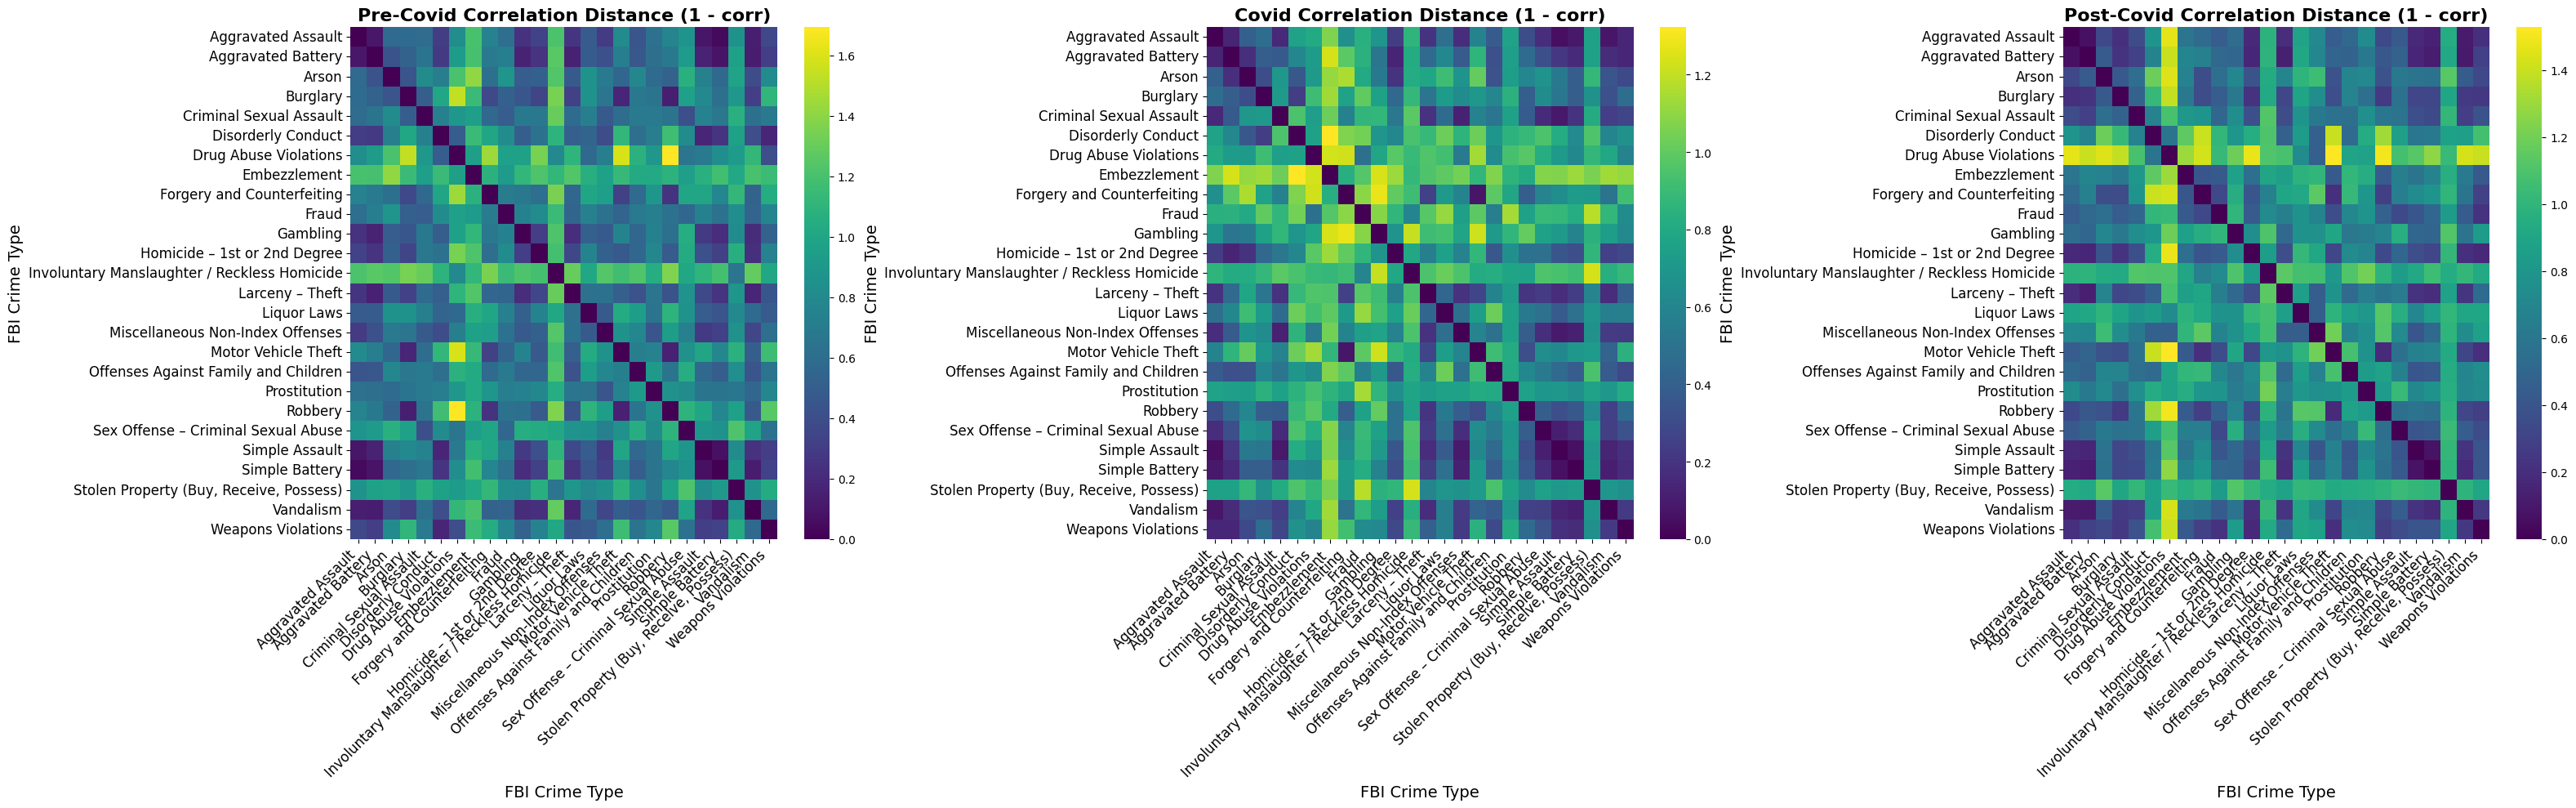

In [12]:
mats=[dist_df_pre, dist_df_covid, dist_df_post]
titles = ["Pre-Covid Correlation Distance (1 - corr)", "Covid Correlation Distance (1 - corr)", "Post-Covid Correlation Distance (1 - corr)"]

# Plot Shape
fig, axes = plt.subplots(1, 3, figsize=(32,10))

# Plot
heatmap_kwargs = {
    "cmap": "viridis",
    "xticklabels": True,
    "yticklabels": True,
    "annot": False,
    "fmt": ".2f",
    "cbar": True
}
# Iterate  each plot
for ax, mat, title in zip(axes, mats, titles):
    sns.heatmap(mat, ax=ax, **heatmap_kwargs)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=12)

    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

    ax.tick_params(axis='y', labelsize=12)
    ax.set_xlabel("FBI Crime Type", fontsize=14)
    ax.set_ylabel("FBI Crime Type", fontsize=14)

plt.tight_layout()
plt.show()

## [PCA (Principal Component Analysis)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
* PCA operates directly on the data matrix, via the covariance or correlation matrix, under a Euclidean geometry assumption.
    * Components are linear combinations of the original variables
    * How much of the total variance in the original data is captured by each component
    * High percentages are common because PCA is optimally reconstructive under Euclidean assumptions
## PCoA (Principal Coordinates Analysis):
* PCoA operates on a pairwise distance (or dissimilarity) matrix
    * May encode complex relationships (correlation, Bray–Curtis, etc.)
    * Coordinates are chosen to best preserve pairwise distances
    * Only positive eigenvalues (negative ones are noise/non-Euclidean artifacts)
## [Procrustes Analysis](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.procrustes.html)
* A statistical method for shape analysis used to compare two sets of data points (shapes)

In [13]:
def compare_pca_pcoa(data, dist_df, n_components=2):
    # PCA Calculation
    pca = PCA(n_components=n_components)
    coords_pca = pca.fit_transform(data.values)
    pca_var = pca.explained_variance_ratio_

    # PCoA Calculation
    D2 = dist_df.values ** 2
    n = D2.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J 

    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

    coords_pcoa = eigvecs[:, :n_components] * np.sqrt(np.maximum(eigvals[:n_components], 0))
    total_pos_variance = np.sum(eigvals[eigvals > 0])
    pcoa_var = eigvals[:n_components] / total_pos_variance

    # Procrustes Alignment
    # mtx_pca and mtx_pcoa are now on the same scale/origin
    mtx_pca, mtx_pcoa, disparity = procrustes(coords_pca, coords_pcoa)

    # Display Output
    print(f"VARIANCE EXPLAINED ({n_components} Components)")
    print("PCA:  " + " & ".join([f"PC{i+1}={v:.2%}" for i, v in enumerate(pca_var)]))
    print("PCoA: " + " & ".join([f"Dim{i+1}={v:.2%}" for i, v in enumerate(pcoa_var)]))
    print(f"\nPROCRUSTES DISPARITY: {disparity:.4f}\n")

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    titles = ["PCA (Aligned)", "PCoA (Aligned)", "Procrustes Overlay"]
    embeddings = [mtx_pca, mtx_pcoa]

    # Plot individual Scatter plots
    for i in range(2):
        ax, emb = axes[i], embeddings[i]
        ax.scatter(emb[:,0], emb[:,1], c='skyblue', s=100, edgecolor='black', alpha=0.7)
        # for j, txt in enumerate(data.index):
        #     ax.annotate(txt, (emb[j,0], emb[j,1]), fontsize=8)
        ax.set_title(titles[i])

    # Plot Overlay
    ax_ov = axes[2]
    ax_ov.scatter(mtx_pca[:,0], mtx_pca[:,1], c='blue', label='PCA', alpha=0.5)
    ax_ov.scatter(mtx_pcoa[:,0], mtx_pcoa[:,1], c='red', label='PCoA', alpha=0.5)
    
    # Draw lines between corresponding points
    for i in range(len(mtx_pca)):
        ax_ov.plot([mtx_pca[i,0], mtx_pcoa[i,0]], 
                   [mtx_pca[i,1], mtx_pcoa[i,1]], 'gray', linestyle='--', alpha=0.3)
    
    ax_ov.set_title(f"{titles[2]} (Disparity: {disparity:.3f})")
    ax_ov.legend()

    plt.tight_layout()
    plt.show()

    return

VARIANCE EXPLAINED (2 Components)
PCA:  PC1=99.42% & PC2=0.29%
PCoA: Dim1=37.67% & Dim2=21.99%

PROCRUSTES DISPARITY: 0.9388



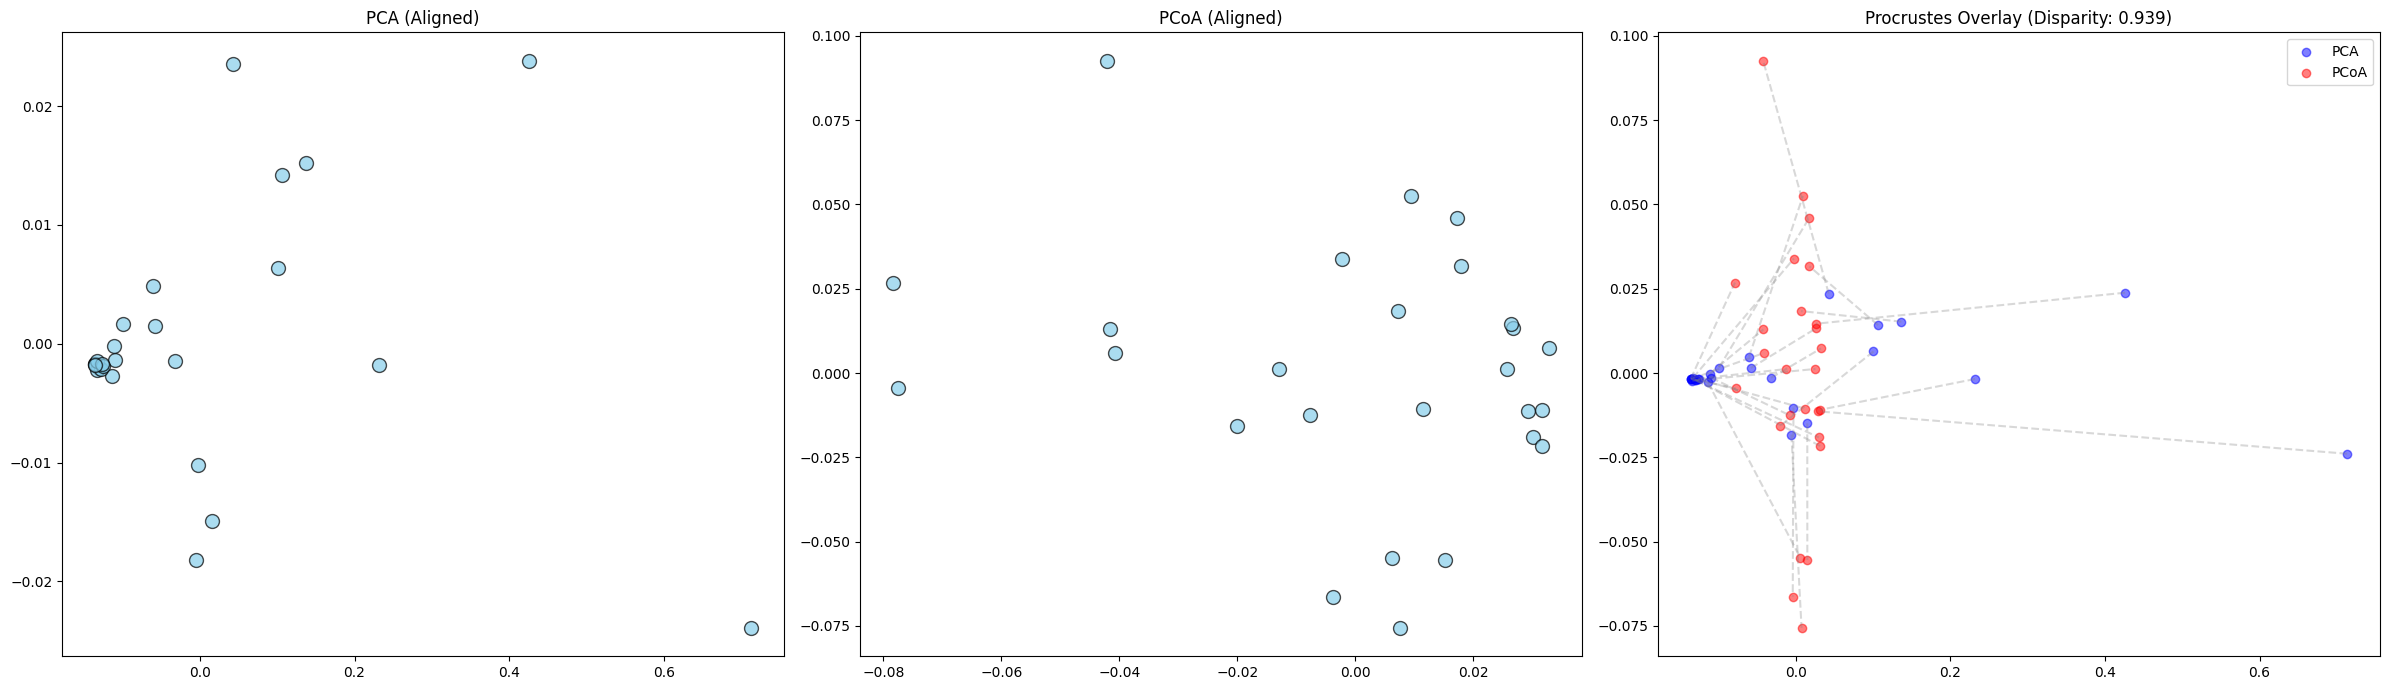

In [14]:
compare_pca_pcoa(z_pivot_pre, dist_df_pre, n_components=2)

#### Given a massive 0.94 disparity, our Correlation Distance (1 - r) tells a completely different story from PCA.
* PCA is misleading since it is only showing the volume of crime. To understand the actual shifting patterns of crime types, we must use PCoA because the underlying structure is fundamentally different.

## Compare Pre-COVID, COVID, and Post-COVID

In [15]:
# Calculate Distance Vectyor & Matrix
dist_df_pre , dist_vec_pre = process_crime_era(z_pivot_pre)
dist_df_covid , dist_vec_covid = process_crime_era(z_pivot_covid)
dist_df_post , dist_vec_post = process_crime_era(z_pivot_post)


Condensed distance vector shape: (325,)
Symmetric distance matrix shape: (26, 26)

Condensed distance vector shape: (325,)
Symmetric distance matrix shape: (26, 26)

Condensed distance vector shape: (325,)
Symmetric distance matrix shape: (26, 26)


In [16]:
from scipy.stats import kruskal, ranksums

# Statistical Testing (Omnibus)
h_stat, p_kruskal = kruskal(dist_vec_pre, dist_vec_covid, dist_vec_post)

# Post-hoc Testing (Pairwise)
# Using Bonferroni correction for 3 comparisons (alpha = 0.05 / 3 = 0.0167)
comparisons = [("Pre vs Covid", dist_vec_pre, dist_vec_covid), 
               ("Covid vs Post", dist_vec_covid, dist_vec_post), 
               ("Pre vs Post", dist_vec_pre, dist_vec_post)]

results = []
for label, v1, v2 in comparisons:
    stat, p_val = ranksums(v1, v2)
    results.append({
        "Comparison": label,
        "P-Value": round(p_val, 4),
        "Significant": p_val < 0.0167, # Adjusted Alpha: 0.05 / 3 = 0.01666
        "Median Diff": round(np.median(v2) - np.median(v1), 4)
    })

# Display Results
print(f"Kruskal-Wallis Test: H={h_stat:.4f}, p={p_kruskal:.4f}")
print("\nPairwise Comparisons:")
print(pd.DataFrame(results))

print("\nMedian Distances (Lower = More Synchronized):")
print(f"Pre: {np.median(dist_vec_pre):.4f} | Covid: {np.median(dist_vec_covid):.4f} | Post: {np.median(dist_vec_post):.4f}")

Kruskal-Wallis Test: H=6.5701, p=0.0374

Pairwise Comparisons:
      Comparison  P-Value  Significant  Median Diff
0   Pre vs Covid   0.0127         True      -0.0146
1  Covid vs Post   0.2812        False      -0.0104
2    Pre vs Post   0.1145        False      -0.0250

Median Distances (Lower = More Synchronized):
Pre: 0.7119 | Covid: 0.6973 | Post: 0.6869


#### The "Big Picture" Result (Omnibus)
* Kruskal-Wallis $p = 0.0374$. Since this is below $0.05$, we have statistically significant evidence that the three eras are not the same. The way crimes "move together" shifted measurably across these periods.

#### The Significant Shift: Pre vs. Covid
P-Value: $0.0127$ (Significant) | Median Diff: $-0.0146$This is your most important finding.
* The Direction: The negative Median Diff means the distance decreased.
* The Interpretation: Crimes became more synchronized during COVID. The pandemic acted as a "systemic shock" that forced disparate crime types to follow a more similar trajectory (likely due to lockdowns and mobility restrictions affecting everything at once).

#### The "New Normal": 
* Covid vs. Post
    * P -Value: $0.2812$ (Not Significant).
    * This suggests that the "behavioral synchronization" that happened during COVID has not reverted to the Pre-COVID state yet. The relationship between crime during the "Post" period is statistically indistinguishable from that during the "Covid" period.

#### The Long-Term Trend
* Median Distances:
    * $0.7119 \rightarrow 0.6973 \rightarrow 0.6869$
    * Analysis of median correlation distances reveals a steady downward trend in dissimilarity ($0.7119 \rightarrow 0.6973 \rightarrow 0.6869$), suggesting that crime types have become increasingly synchronized over time. While the immediate shift from Pre-COVID to COVID was statistically significant ($p = 0.0127$), the long-term shift from Pre-COVID to Post-COVID ($p = 0.1145$) did not meet the strict Bonferroni-corrected threshold ($0.0167$), indicating that while a trend is visible, it has not yet reached a level of high statistical certainty.

## PLOT Era PCoA

In [17]:
def compare_to_pre_covid(dist_pre, dist_covid, dist_post, n_components=2):
    def get_pcoa(dist_df):
        # Traditional PCoA / Classical MDS
        D2 = dist_df.values ** 2
        n = D2.shape[0]
        J = np.eye(n) - np.ones((n, n)) / n
        B = -0.5 * J @ D2 @ J
        eigvals, eigvecs = np.linalg.eigh(B)
        idx = np.argsort(eigvals)[::-1]
        # Use maximum(0) to handle floating point noise in non-Euclidean distances
        coords = eigvecs[:, idx][:, :n_components] * np.sqrt(np.maximum(eigvals[idx][:n_components], 0))
        return coords

    # Generate Coordinates
    coords_pre = get_pcoa(dist_pre)
    coords_covid = get_pcoa(dist_covid)
    coords_post = get_pcoa(dist_post)

    # Procrustes Alignment (Pre-COVID is always the FIRST argument)
    # This standardizes Pre-COVID and aligns the others to it
    pre_std, covid_aligned, disp_covid = procrustes(coords_pre, coords_covid)
    _, post_aligned, disp_post = procrustes(coords_pre, coords_post)

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    eras = [
        (covid_aligned, "COVID", "red", axes[0], disp_covid),
        (post_aligned, "Post-COVID", "green", axes[1], disp_post)
    ]

    for aligned_data, name, color, ax, disp in eras:
        # Plot Baseline
        ax.scatter(pre_std[:, 0], pre_std[:, 1], c='blue', s=100, label='Pre-COVID (Baseline)', alpha=0.4, edgecolors='k')
        # Plot Target Era
        ax.scatter(aligned_data[:, 0], aligned_data[:, 1], c=color, s=100, label=f'{name} Era', alpha=0.8, edgecolors='k')
        
        # Draw "Stress Lines" (Vectors of change)
        for i in range(len(pre_std)):
            ax.plot([pre_std[i, 0], aligned_data[i, 0]], 
                    [pre_std[i, 1], aligned_data[i, 1]], 
                    'gray', linestyle='--', alpha=0.4)
            # Label the crimes on the baseline points
            ax.text(pre_std[i, 0], pre_std[i, 1], dist_pre.index[i], fontsize=9)

        ax.set_title(f"Shift: Pre-COVID --> {name}\nDisparity: {disp:.4f}", fontsize=14)
        ax.legend()
        ax.set_xlabel("PCoA Dim 1")
        ax.set_ylabel("PCoA Dim 2")

    plt.tight_layout()
    plt.show()

    return {
        "pre_std": pre_std, 
        "covid_aligned": covid_aligned, 
        "post_aligned": post_aligned,
        "disp_covid": disp_covid, 
        "disp_post": disp_post,
        "index_names": dist_pre.index
    }

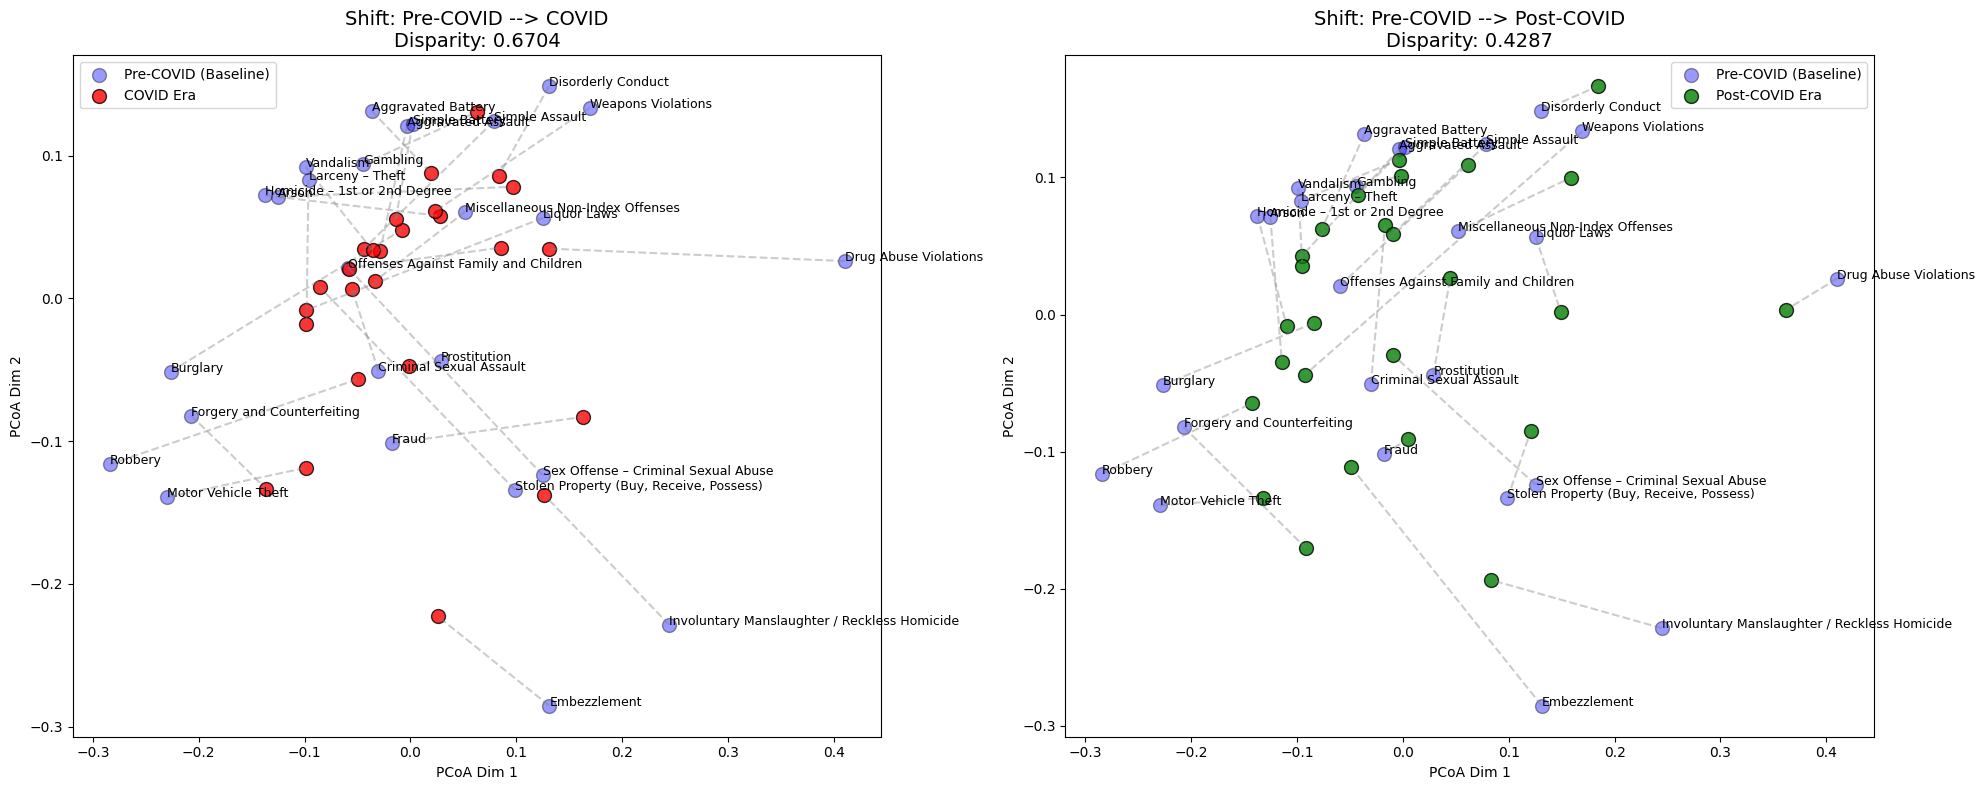

In [18]:
# Plot
results = compare_to_pre_covid(dist_df_pre, dist_df_covid, dist_df_post, n_components=2)

#### In our Procrustes analysis, Disparity (often called $M^2$) measures the total lack of fit between two shapes. Since Pre-COVID, our 0.0 baseline (the "normal" state), these numbers represent the total structural distortion of the city's crime patterns. In Procrustes analysis, disparity measures how much you have to "stretch" or "bend" one era to make it look like the baseline.
  
#### The COVID "Shock": 0.6704
* In PCoA space, this means the eigenvectors (the underlying forces driving crime patterns) were rotated and stretched so severely that the "neighborhoods" of crime types were completely rearranged.

#### The Post-COVID "Partial Reset": 0.4287
* A drop from 0.67 to 0.43 ($\approx$ 36% decrease) is significant because it marks the transition from a state of chaos to a state of reorganization.
* This means that in the PCoA plot, the dots representing each crime are migrating back toward their Pre-COVID coordinates, even if they haven't arrived yet.

#### Value Range	
* 0.00 – 0.05	Almost no change in pattern.
    * Static / Anchored
* 0.06 – 0.15	Slight shift in relationship to other crimes.
    * Stable
* 0.16 – 0.22	Noticeable change
    * Volatile
* 0.23+	Radical departure from Pre-COVID
    * Regime Shift

In [19]:
def get_top_movers(pre_std, aligned_data, index, top_n=5):
    # Calculate Euclidean distance (residuals) since 
    # (pre_std and aligned_data) is in a physical location in a 2D space
    residuals = np.sqrt(np.sum((pre_std - aligned_data)**2, axis=1))
    
    # Create a Series for easy sorting
    mover_series = pd.Series(residuals, index=index)
    return mover_series.sort_values(ascending=False).head(top_n)

# Extract the variables from the results dictionary
pre_std = results["pre_std"]
covid_aligned = results["covid_aligned"]
post_aligned = results["post_aligned"]

# Usage:
covid_movers = get_top_movers(pre_std, covid_aligned, dist_df_pre.index)
post_movers = get_top_movers(pre_std, post_aligned, dist_df_pre.index)

print("TOP MOVERS (COVID):")
print(covid_movers)
print("\nTOP MOVERS (POST-COVID):")
print(post_movers)

TOP MOVERS (COVID):
fbi_code_desc
Drug Abuse Violations                  0.279629
Robbery                                0.242139
Burglary                               0.240178
Liquor Laws                            0.233549
Sex Offense – Criminal Sexual Abuse    0.233272
dtype: float64

TOP MOVERS (POST-COVID):
fbi_code_desc
Weapons Violations                              0.316119
Embezzlement                                    0.250251
Involuntary Manslaughter / Reckless Homicide    0.165083
Sex Offense – Criminal Sexual Abuse             0.164914
Robbery                                         0.150170
dtype: float64


In [20]:
def get_stability_ranking(pre_std, aligned_data, index, top_n=5):
    # Calculate Euclidean distance (residuals) since 
    # (pre_std and aligned_data) is in a physical location in a 2D space
    residuals = np.sqrt(np.sum((pre_std - aligned_data)**2, axis=1))
    
    # Create Series: Lowest values = Most Stable
    stability_series = pd.Series(residuals, index=index)
    return stability_series.sort_values(ascending=True).head(top_n)

# Run it for Post-COVID
stable_crimes = get_stability_ranking(results["pre_std"], results["post_aligned"], results["index_names"])
print("MOST STABLE CRIMES (POST-COVID):\n", stable_crimes)

MOST STABLE CRIMES (POST-COVID):
 fbi_code_desc
Fraud                                      0.024504
Gambling                                   0.042829
Stolen Property (Buy, Receive, Possess)    0.053662
Drug Abuse Violations                      0.053697
Disorderly Conduct                         0.056151
dtype: float64
